# The Cross-Section

*the same method when the unit of analysis is the cross-section*

## The question

A panel has many entities on each date. That changes the safe feature transform, the split and
often the metric: shifts must stay within an entity, validation must move whole dates, and a
ranking task should be judged by its cross-sectional ordering rather than raw scale alone.

## Volatility project path

Start with the shorter [volatility project panel notebook](volatility_project_03_panel.ipynb). In this deep
reference, the core route is [R5.3](#r5-3), [R5.8](#r5-8)–[R5.18](#r5-18),
[R5.20](#r5-20)–[R5.24](#r5-24), [R5.28](#r5-28), [R5.30](#r5-30) and
[R5.31](#r5-31)–[R5.34](#r5-34). It covers the panel audit, causal features, date-safe
validation, baselines, Ridge/boosters, OOF interpretation, refit and submission.

Memory optimization, broad tuning, blending/stacking, streaming replay and manifests are
optional extensions. They remain here because they matter in larger projects, but they should
not delay a credible baseline and validation table in a timed exercise.

Four panel-specific failure modes remain load-bearing: an ungrouped shift crosses securities;
a row split shares dates; the label horizon crosses an unpurged boundary; and inference may
not expose the full same-date cross-section assumed by rank or de-mean features.

> **Provenance:** stored outputs describe the data and paths printed in that run. Rerun top
> to bottom before treating them as results for the files currently available.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,not found
○ smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
○ smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
○ smile_5d,Near-tenor only.
○ chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
N_ENTITIES  = 400        # only used by the synthetic fallback
N_DATES     = 500
HORIZONS    = (1, 5, 20)  # return lookbacks, in trading days
WINDOWS     = (5, 20)     # rolling-statistic windows
GROUP_COL   = "Sector"    # the grouping for sector-relative features
DEMEAN_TARGET = True      # remove each date's mean from the label
SEED        = 42
N_SPLITS     = 4
GAP_DAYS     = 2          # the label horizon: Target(t) uses prices at t+1 and t+2
HOLDOUT_FRAC = 0.15
PORTFOLIO_K  = 40         # long the top k, short the bottom k (200 in the real JPX)
MODELS       = ("ridge", "lgbm", "xgb")
FAST_MODE    = True       # smaller grids; set False for the full search
STREAM_DAYS  = 12         # days to replay through the simulated inference loop
BUFFER_DAYS  = 40         # must exceed the longest rolling window

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
from rvlab.data import load_panel

df = load_panel(n_entities=N_ENTITIES, n_dates=N_DATES, seed=SEED)
print(df.attrs["provenance"])
df.head(3)

{'source': 'synthetic', 'synthetic': True, 'rows': 200000, 'planted_effect': 'short-term reversal, coefficient 0.1', 'hint': 'set $RVLAB_PANEL_ROOT to an unzipped competition directory'}


,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target,RowId,Sector,MarketCapitalization,IssuedShares
0,2021-01-04,1301,987.9820,990.2212,969.7859,981.5454,106742.0,1.0,NaN,False,0.0117,20210104_1301,Technology,3.9389e+11,5.9224e+07
1,2021-01-04,1302,996.3583,1029.9421,961.1223,964.6447,61532.0,1.0,NaN,False,0.0505,20210104_1302,Utilities,4.5585e+10,1.6203e+08
2,2021-01-04,1303,1003.8561,1023.8309,994.0247,1016.8456,859308.0,1.0,NaN,False,0.0366,20210104_1303,Materials,2.7263e+10,2.8919e+08


## Recipes in this notebook

**The cross-sectional design**

| Recipe | What it does |
|---|---|
| [R5.1](#r5-1) | Find the dataset wherever it happens to live |
| [R5.2](#r5-2) | Concatenate train and supplemental files, then de-duplicate |
| [R5.3](#r5-3) | Audit the panel before touching a model |
| [R5.4](#r5-4) | Plot coverage over time |
| [R5.5](#r5-5) | Look at the target distribution before modelling it |
| [R5.6](#r5-6) | Compare distributions across groups |
| [R5.7](#r5-7) | Reduce memory before it becomes the bottleneck |
| [R5.8](#r5-8) | Build calendar and same-bar price geometry |
| [R5.9](#r5-9) | Multi-horizon returns, masked where corporate actions intrude |
| [R5.10](#r5-10) | Rolling statistics and z-scores, within each entity |
| [R5.11](#r5-11) | Cross-sectional rank and de-mean — the panel-specific transform |
| [R5.12](#r5-12) | Subtract the group's mean — sector-relative features |
| [R5.13](#r5-13) | De-mean the target within each date |
| [R5.14](#r5-14) | Audit for leakage by name, and assert on it |

**Estimating a ranking, and validating it honestly**

| Recipe | What it does |
|---|---|
| [R5.15](#r5-15) | Separate identifiers, features and labels — once |
| [R5.16](#r5-16) | Split dates, not rows — then map back to row indices |
| [R5.17](#r5-17) | Set aside a purged block of dates for model validation |
| [R5.18](#r5-18) | Score the objective, not a convenient proxy |
| [R5.19](#r5-19) | Watch RMSE disagree with the ranking metrics |
| [R5.20](#r5-20) | Build a mixed-dtype pipeline for a panel |
| [R5.21](#r5-21) | Tune with GridSearchCV on the purged folds |
| [R5.22](#r5-22) | Fit every model on the same folds and compare on the objective |
| [R5.23](#r5-23) | Look at the IC path, not just its mean |
| [R5.24](#r5-24) | Plot what the portfolio would actually have earned |

**Combining models, and shipping one**

| Recipe | What it does |
|---|---|
| [R5.25](#r5-25) | Put predictions on a common scale before averaging them |
| [R5.26](#r5-26) | Choose blend weights out of sample |
| [R5.27](#r5-27) | Generate out-of-fold predictions for stacking |
| [R5.28](#r5-28) | Read importance out of a fitted pipeline |
| [R5.29](#r5-29) | Aggregate one-hot importances back to their source column |
| [R5.30](#r5-30) | Use permutation importance when the others disagree |
| [R5.31](#r5-31) | Refit on everything once selection is finished |
| [R5.32](#r5-32) | Check the inference schema before predicting |
| [R5.33](#r5-33) | Carry a rolling history buffer for streaming inference |
| [R5.34](#r5-34) | Turn predictions into a valid submission |
| [R5.35](#r5-35) | Run the streaming loop end to end before you trust it |
| [R5.36](#r5-36) | Write a manifest so the run can be reproduced |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

A panel breaks in ways a single series cannot, and every one of them produces a validation score that looks better than the truth.

**Python and pandas**

* **Know whether you want `transform` or an aggregate-and-join.** `groupby(...).transform`
  returns something index-aligned to the original rows; `.agg` returns one row per group and
  has to be merged back. Mixing them up is a silent misalignment.
* **Downcast on big panels.** `float64` → `float32` and low-cardinality strings → `category`
  routinely halves memory, which decides whether the notebook runs at all.
* **Always pass `validate=` and `indicator=` to `merge`.** They turn the two most common join
  bugs — fan-out and non-matching keys — into an exception and a column you can count.
* **`rank(method="first")` when the grader wants unique integers.** The default `"average"`
  produces ties and `.5`s, which is a rejected submission.

**Analysis**

* **Split dates, not rows, and leave a gap.** The label at *t* is built from *t+1* and
  *t+2*, so the last training dates carry validation information. Both the row-split and the
  gapless date-split leak.
* **Score the estimand you will act on.** RMSE and rank IC can disagree completely: [R5.19](#r5-19)
  prints the active run's RMSE ratio for two predictions that induce the same ranking.
* **Put predictions on a common per-date scale before blending**, or a plain average is
  implicitly weighted by prediction spread rather than by skill.
* **Test that streaming and batch inference agree.** Serving code that differs slightly from
  training code is where validated models fail; a rank correlation of 1.0000 is the check.


## The cross-sectional design

The panel itself: what a (date × entity) frame is, how it breaks, and the transforms that only exist because the cross-section is information.

## R5.1 · Find the dataset wherever it happens to live
<a id="r5-1"></a>

**Topic** Data discovery

**Use when** the data is in a different place on every machine — a Kaggle input mount, a Downloads folder, a sibling directory. Search for a known *file* instead of hard-coding a path.

**Inputs** a marker path such as `train_files/stock_prices.csv`.

**Needs** nothing beyond the setup and data cells

**Gotchas** search upward through parents before searching downward. A downward `rglob` from a home directory can take minutes and match the wrong copy.

**See also** [R5.2](#r5-2) (loading it) · [R1.6](the_volatility_surface.ipynb#r1-6) (a simpler catalogue)

In [4]:
from rvlab.data import find_dataset_root

root = find_dataset_root("train_files/stock_prices.csv")
print(root or "not found — the synthetic fallback will be used")
print("set $RVLAB_PANEL_ROOT to point at a real competition directory")

not found — the synthetic fallback will be used
set $RVLAB_PANEL_ROOT to point at a real competition directory


## R5.2 · Concatenate train and supplemental files, then de-duplicate
<a id="r5-2"></a>

**Topic** File I/O

**Use when** the competition ships a frozen `train_files/` plus a rolling `supplemental_files/` that overlaps it. Concatenate, then drop duplicate keys keeping the *later* folder.

**Inputs** a dataset root.

**Needs** R5.1 — run those first. This recipe builds on what they define.

**Gotchas** `keep="last"` matters — the supplement carries corrections, so it must win. Recording a `_source_folder` column costs nothing and is the first thing you want when the concatenated frame looks wrong.

**See also** [R5.1](#r5-1) (finding the root) · [R5.3](#r5-3) (auditing the result)

In [5]:
from rvlab.data import concat_folders, read_if_exists

if root is not None:
    prices = concat_folders(root, "stock_prices.csv")
    print(prices["_source_folder"].value_counts().to_string())
else:
    print("no real dataset found; `df` from the swap-data cell is the synthetic panel")
    print(f"{len(df):,} rows, {df['Date'].nunique()} dates, "
          f"{df['SecuritiesCode'].nunique()} entities")

no real dataset found; `df` from the swap-data cell is the synthetic panel
200,000 rows, 500 dates, 400 entities


## R5.3 · Audit the panel before touching a model
<a id="r5-3"></a>

**Topic** Health check

**Use when** immediately after loading, always. Each check here catches a failure that produces a *plausible wrong answer* rather than an error — which is the only kind that survives to your final report.

**Inputs** `df` with a date column, an entity column and a target.

**Needs** nothing beyond the setup and data cells

**Gotchas** duplicate (date, entity) rows are the nastiest: they silently double-weight an observation, and every metric still computes.

**See also** [R5.4](#r5-4) (coverage over time) · [R1.11](the_volatility_surface.ipynb#r1-11) (schema contracts)

In [6]:
from rvlab.data import audit_panel

audit = audit_panel(df)
audit

rows,200000
dates,500
entities,400
date_min,2021-01-04
date_max,2022-12-02
entities_per_date_median,400
entities_per_date_min,400
duplicate_keys,0
memory_mb,43.4
target_missing_rate,0.004


The four questions this answers, in order of how often they matter: are keys unique, is coverage stable, how much of the target is missing, and how big is this thing in memory.

In [7]:
print("clean" if audit.ok else "PROBLEMS:")
for problem in audit.problems:
    print("  -", problem)

clean


## R5.4 · Plot coverage over time
<a id="r5-4"></a>

**Topic** Health check

**Use when** any panel. The entity count per date is the single most informative plot in a panel audit: a step down is a delisting wave or a truncated file, a step up is new listings.

**Inputs** `df` with date and entity columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** a metric averaged across a coverage break averages two different universes. If you see a step, decide explicitly whether to trim the panel or to condition on the regime.

**See also** [R5.3](#r5-3) (the audit) · [R5.5](#r5-5) (target distribution)

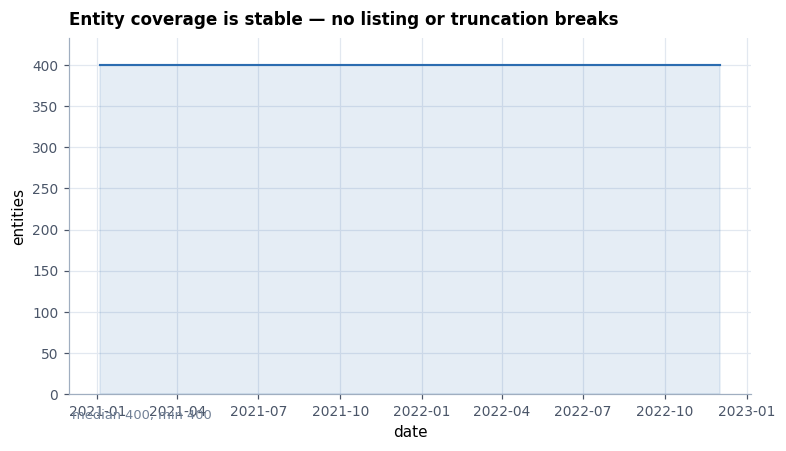

In [8]:
from rvlab.plotting import coverage_plot

coverage_plot(df, title="Entity coverage is stable — no listing or truncation breaks");

## R5.5 · Look at the target distribution before modelling it
<a id="r5-5"></a>

**Topic** Exploratory analysis

**Use when** before choosing a loss. Financial targets are near-zero-mean with very heavy tails, which is why squared loss chases outliers and why ranking metrics behave better.

**Inputs** `df` with a `Target` column.

**Needs** nothing beyond the setup and data cells

**Gotchas** clip the *display*, never the data. A handful of extreme returns will otherwise compress the whole histogram into one bar and hide the shape entirely.

**See also** [R5.4](#r5-4) (coverage) · [R1.14](the_volatility_surface.ipynb#r1-14) (describe with tail percentiles)

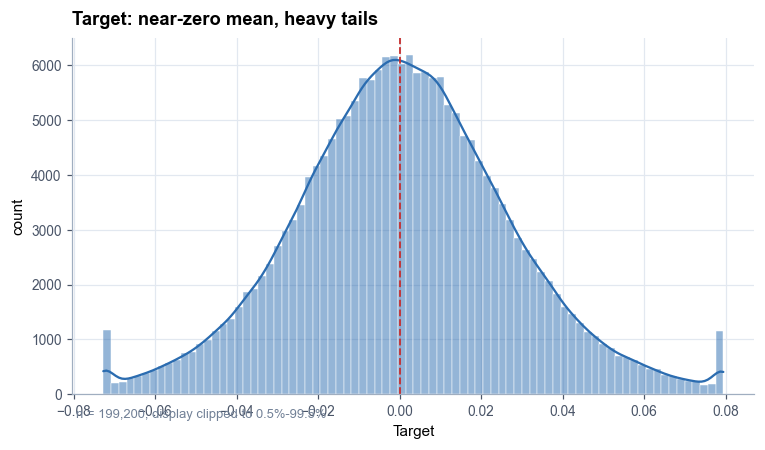

In [9]:
from rvlab.plotting import target_distribution_plot

target_distribution_plot(df, title="Target: near-zero mean, heavy tails");

The numbers behind the picture. The ratio of the 99th percentile to the standard deviation is the quickest read on tail weight — for a normal distribution it is about 2.3.

In [10]:
t = df["Target"].dropna()
print(f"mean {t.mean():+.5f}  std {t.std():.5f}  skew {t.skew():+.2f}  kurtosis {t.kurt():+.1f}")
print(f"p99 / std = {t.quantile(0.99) / t.std():.2f}   (2.3 would be normal)")

mean +0.00088  std 0.02713  skew +0.10  kurtosis +0.7
p99 / std = 2.58   (2.3 would be normal)


## R5.6 · Compare distributions across groups
<a id="r5-6"></a>

**Topic** Exploratory analysis

**Use when** the panel has a categorical dimension — sector, region, product line. A boxplot per group shows whether the grouping carries information worth a feature.

**Inputs** `df` with a numeric column and a categorical column.

**Needs** nothing beyond the setup and data cells

**Gotchas** compare *spreads*, not just medians. Groups with equal medians and very different dispersion behave completely differently in a ranking model, and a bar of means hides that entirely.

**See also** [R5.11](#r5-11) (group-relative features) · [R1.22](the_volatility_surface.ipynb#r1-22) (correlation)

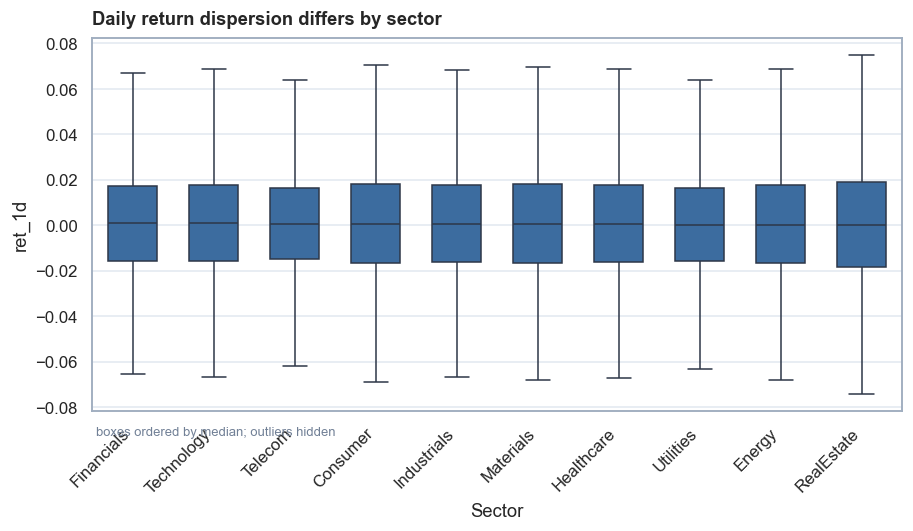

In [11]:
from rvlab.features import add_horizon_returns, add_price_geometry
from rvlab.plotting import group_box_plot

geometry = add_horizon_returns(add_price_geometry(df), horizons=(1,))
group_box_plot(geometry, "ret_1d", GROUP_COL,
               title="Daily return dispersion differs by sector");

## R5.7 · Reduce memory before it becomes the bottleneck
<a id="r5-7"></a>

**Topic** Memory

**Use when** the panel is large. Competition panels reach tens of millions of rows; downcasting floats and converting low-cardinality strings to `category` routinely halves the footprint and speeds every groupby.

**Inputs** `df`.

**Needs** nothing beyond the setup and data cells

**Gotchas** `float32` carries ~7 significant digits — fine for prices and returns, not fine for accumulating sums. Downcast the columns you *store*, not the ones you compute with.

**See also** [R5.3](#r5-3) (the audit reports memory) · [R1.9](the_volatility_surface.ipynb#r1-9) (the same idea)

In [12]:
before = df.memory_usage(deep=True).sum() / 1e6
compact = df.copy()
for col in compact.select_dtypes("float64"):
    compact[col] = compact[col].astype("float32")
for col in compact.select_dtypes("object"):
    if compact[col].nunique() < 0.5 * len(compact):
        compact[col] = compact[col].astype("category")

print(f"{before:.1f} MB -> {compact.memory_usage(deep=True).sum() / 1e6:.1f} MB")

43.4 MB -> 24.0 MB


## R5.8 · Build calendar and same-bar price geometry
<a id="r5-8"></a>

**Topic** Feature engineering

**Use when** the first feature block. Calendar effects are cheap and occasionally real; same-bar OHLCV shape is fully observable at that bar's close.

**Inputs** `df` with OHLCV columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** `close_location` — where the close sits inside the day's range — is the one worth knowing about. It separates 'up on the day' from 'up on the day and closed on the high'.

**See also** [R5.9](#r5-9) (returns) · [R3.1](forecasting_the_smile.ipynb#r3-1) (the equivalent for a smile panel)

In [13]:
from rvlab.features import add_calendar_features, add_price_geometry

feat = add_price_geometry(add_calendar_features(df))
new = [c for c in feat.columns if c not in df.columns]
print(f"{len(new)} columns added:", new)
feat[["Date", "SecuritiesCode", "intraday_return", "range_pct",
      "close_location", "log_volume"]].head(3)

15 columns added: ['year', 'month', 'dayofweek', 'dayofmonth', 'weekofyear', 'is_month_end', 'intraday_return', 'range_pct', 'close_location', 'log_volume', 'log_dollar_volume', 'dividend_flag', 'expected_dividend_yield', 'supervision_flag', 'corporate_action_flag']


,Date,SecuritiesCode,intraday_return,range_pct,close_location,log_volume
0,2021-01-04,1301,-0.0065,0.0208,0.5755,11.5782
1,2021-01-04,1302,-0.0318,0.0713,0.0512,11.0273
2,2021-01-04,1303,0.0129,0.0293,0.7656,13.6639


## R5.9 · Multi-horizon returns, masked where corporate actions intrude
<a id="r5-9"></a>

**Topic** Feature engineering

**Use when** you need momentum and reversal features at several lookbacks. Computed per entity, with any window containing a split or reverse split masked out.

**Inputs** `feat` from [R5.8](#r5-8), with an `AdjustmentFactor` column when available.

**Needs** R5.8 — run those first. This recipe builds on what they define.

**Gotchas** a 2-for-1 split halves the raw close, so a 5-day return across it reads as −50%. Splits cluster in time, so that fiction is **correlated across entities** — exactly the kind of structure a model will happily learn. The usual alternative, a reverse cumulative adjustment factor, is computed from *future* actions and leaks during validation.

**See also** [R5.8](#r5-8) (geometry) · [R5.10](#r5-10) (rolling stats)

In [14]:
from rvlab.features import add_horizon_returns

feat = add_horizon_returns(feat, horizons=HORIZONS)
n_masked = feat["corporate_action_flag"].sum()
print(f"{n_masked:,} corporate actions; "
      f"ret_1d missing on {feat['ret_1d'].isna().mean():.2%} of rows")
feat[["Date", "SecuritiesCode", *[f"ret_{h}d" for h in HORIZONS]]].tail(3)

86 corporate actions; ret_1d missing on 0.29% of rows


,Date,SecuritiesCode,ret_1d,ret_5d,ret_20d
199199,2022-11-30,1700,0.0283,0.0834,-0.0669
199599,2022-12-01,1700,0.0155,0.0512,-0.0025
199999,2022-12-02,1700,-0.0174,0.0251,-0.0183


> ⚠️ **Look-ahead:** the masking uses only the action flag *at each date*, which is knowable then. Verify that the first rows of each entity are NaN — if they are not, the return has wrapped around into the previous security.

In [15]:
first = feat.sort_values(["SecuritiesCode", "Date"]).groupby("SecuritiesCode").head(1)
print(f"ret_1d NaN on the first row of every entity: {first['ret_1d'].isna().all()}")

ret_1d NaN on the first row of every entity: True


## R5.10 · Rolling statistics and z-scores, within each entity
<a id="r5-10"></a>

**Topic** Feature engineering

**Use when** you want trend and volatility context. Rolling mean/std of returns, and a rolling z-score of volume.

**Inputs** `feat` with `ret_1d` and `log_volume`.

**Needs** R5.8, R5.9 — run those first. This recipe builds on what they define.

**Gotchas** a rolling **z-score** is usually more useful than the level for a cross-entity model: 3 million shares is enormous for one stock and a quiet day for another, and only the z-score makes them comparable.

**See also** [R5.9](#r5-9) (returns) · [R3.3](forecasting_the_smile.ipynb#r3-3) (grouped rolling)

In [16]:
from rvlab.features import add_entity_rolling

feat = add_entity_rolling(feat, ["ret_1d", "log_volume"], windows=WINDOWS,
                          zscore_of=["log_volume"])
[c for c in feat.columns if "log_volume" in c]

['log_volume',
 'log_volume_mean5',
 'log_volume_std5',
 'log_volume_mean20',
 'log_volume_std20',
 'log_volume_z5',
 'log_volume_z20']

## R5.11 · Cross-sectional rank and de-mean — the panel-specific transform
<a id="r5-11"></a>

**Topic** Cross-sectional features

**Use when** always, on a ranking problem. Rank and de-mean each feature *within its date*. This is the single highest-value transform in panel modelling.

**Inputs** `feat` and a list of columns.

**Needs** R5.8, R5.9 — run those first. This recipe builds on what they define.

**Gotchas** `cs_rank_x` is bounded in [0, 1], immune to the fat tails that dominate raw returns, and comparable across dates with wildly different volatility. De-meaning uses the **median**, so one bad print cannot shift the cross-section.

**See also** [R5.12](#r5-12) (group-relative) · [R5.16](the_cross_section.ipynb#r5-16) (why it helps)

In [17]:
from rvlab.features import add_cross_sectional

cs_cols = [f"ret_{h}d" for h in HORIZONS] + ["intraday_return", "range_pct",
                                             "log_dollar_volume", "close_location"]
feat = add_cross_sectional(feat, cs_cols)
print(f"{2 * len(cs_cols)} cross-sectional columns added")
feat[["Date", "ret_1d", "cs_rank_ret_1d", "cs_demean_ret_1d"]].head(3)

14 cross-sectional columns added


,Date,ret_1d,cs_rank_ret_1d,cs_demean_ret_1d
0,2021-01-04,NaN,NaN,NaN
400,2021-01-05,-0.0024,0.5238,0.0011
800,2021-01-06,0.0117,0.5689,0.0026


The payoff, measured. Compare the absolute correlations below: the active data decides whether removing the common date move strengthened this signal.

In [18]:
scored = feat.dropna(subset=["Target", "ret_1d", "cs_rank_ret_1d"])
for col in ["ret_1d", "cs_rank_ret_1d"]:
    print(f"  corr({col:16s}, Target) = {scored[[col, 'Target']].corr().iloc[0, 1]:+.4f}")

  corr(ret_1d          , Target) = -0.0605
  corr(cs_rank_ret_1d  , Target) = -0.0750


## R5.12 · Subtract the group's mean — sector-relative features
<a id="r5-12"></a>

**Topic** Cross-sectional features

**Use when** you know a grouping that drives common variation. Subtracting the sector's same-date mean is a sharper control than de-meaning against the whole cross-section.

**Inputs** `feat` with a group column.

**Needs** R5.8, R5.9, R5.11 — run those first. This recipe builds on what they define.

**Gotchas** still causal — every entity in the group is observable on that date. Verify it constructed correctly: each (date, group) cell must average to exactly zero.

**See also** [R5.11](#r5-11) (cross-sectional) · [R5.6](#r5-6) (is the grouping informative?)

In [19]:
from rvlab.features import add_group_relative

feat = add_group_relative(feat, [f"ret_{h}d" for h in HORIZONS], group_col=GROUP_COL)
check = feat.dropna(subset=["ret_1d_vs_group"]).groupby(["Date", GROUP_COL])
print(f"max |mean| within (date, {GROUP_COL}): "
      f"{check['ret_1d_vs_group'].mean().abs().max():.2e}  (must be ~0)")

max |mean| within (date, Sector): 7.34e-18  (must be ~0)


Whether the extra step earned anything, on this data:

In [20]:
scored = feat.dropna(subset=["Target", "ret_1d", "cs_rank_ret_1d", "ret_1d_vs_group"])
for col in ["ret_1d", "cs_rank_ret_1d", "ret_1d_vs_group"]:
    print(f"  corr({col:18s}, Target) = {scored[[col, 'Target']].corr().iloc[0, 1]:+.4f}")

  corr(ret_1d            , Target) = -0.0605
  corr(cs_rank_ret_1d    , Target) = -0.0750
  corr(ret_1d_vs_group   , Target) = -0.0816


## R5.13 · De-mean the target within each date
<a id="r5-13"></a>

**Topic** Target construction

**Use when** the objective is ranking rather than forecasting. The market's daily move shifts every entity's target together and cannot change their order, so removing it removes nuisance variance without touching the thing you are scored on.

**Inputs** `feat` with a `Target` column.

**Needs** R5.8 — run those first. This recipe builds on what they define.

**Gotchas** this uses labels *within a date only*, and is not needed at inference: ranking is invariant to adding a constant to every prediction on a date. It usually makes RMSE look worse while improving rank IC — which is why you must not select on RMSE.

**See also** [R5.11](#r5-11) (the same logic for features) · [R5.17](the_cross_section.ipynb#r5-17) (ranking metrics)

In [21]:
from rvlab.features import make_panel_target

feat = make_panel_target(feat, demean=DEMEAN_TARGET)
day = feat[feat["Date"] == feat["Date"].iloc[len(feat) // 2]].dropna(subset=["Target"])
print(f"within-date mean of ModelTarget: {feat.groupby('Date')['ModelTarget'].mean().abs().max():.2e}")
print(f"ordering preserved: {(day['Target'].rank().to_numpy() == day['ModelTarget'].rank().to_numpy()).all()}")

within-date mean of ModelTarget: 3.41e-18
ordering preserved: True


## R5.14 · Audit for leakage by name, and assert on it
<a id="r5-14"></a>

**Topic** Leakage

**Use when** before every fit. A name-based scan for label-shaped columns costs nothing, runs in CI, and catches the most damaging class of mistake: a future column that survived a merge from an auxiliary table.

**Inputs** the feature list you are about to hand a model.

**Needs** R5.8 — run those first. This recipe builds on what they define.

**Gotchas** crude but effective. It cannot catch a leak with an innocent name — for that you need the reasoning in [R3.2](forecasting_the_smile.ipynb#r3-2) — but it catches the common case, which is a `Target` column arriving through a join you forgot about.

**See also** [R3.2](forecasting_the_smile.ipynb#r3-2) (the full taxonomy) · [R5.15](the_cross_section.ipynb#r5-15) (splitting)

In [22]:
from rvlab.data import leakage_audit

identifiers = {"Date", "SecuritiesCode", "RowId", "Target", "ModelTarget", "_source_folder"}
feature_cols = [c for c in feat.columns if c not in identifiers]

leaky = leakage_audit(feature_cols)
assert not leaky, f"label-shaped columns in the feature list: {leaky}"
print(f"{len(feature_cols)} features, no label-shaped names")

57 features, no label-shaped names


What it catches when something does slip through — here, a `Target` column arriving under a different name from a secondary table:

In [23]:
print("would be flagged:", leakage_audit(
    ["Close", "ret_1d", "secondary_Target", "next_day_label", "future_vol"]))

would be flagged: ['secondary_Target', 'next_day_label', 'future_vol']


## Estimating a ranking, and validating it honestly

Two decisions that outrank the choice of algorithm — where to split, and what to score — and only then the models.

Its data cell binds `df`.

In [24]:
from rvlab.data import load_panel
from rvlab.features import build_panel_features

df = build_panel_features(load_panel(n_entities=N_ENTITIES, n_dates=N_DATES, seed=SEED))
df = df.dropna(subset=["ModelTarget"]).reset_index(drop=True)
print(f"{len(df):,} rows · {df['Date'].nunique()} dates · {df.shape[1]} columns")
df[["Date", "SecuritiesCode", "ret_1d", "cs_rank_ret_1d", "Target", "ModelTarget"]].head(3)

199,200 rows · 498 dates · 62 columns


,Date,SecuritiesCode,ret_1d,cs_rank_ret_1d,Target,ModelTarget
0,2021-01-04,1301,NaN,NaN,0.0117,0.0032
1,2021-01-04,1302,NaN,NaN,0.0505,0.0419
2,2021-01-04,1303,NaN,NaN,0.0366,0.0281


## R5.15 · Separate identifiers, features and labels — once
<a id="r5-15"></a>

**Topic** Feature selection

**Use when** before any fit. Decide explicitly which columns are identifiers, which are labels and which are features, and derive the numeric/categorical split from dtypes rather than by hand.

**Inputs** `df`.

**Needs** nothing beyond the setup and data cells

**Gotchas** two traps. Keep the entity id **out** of the numeric block — `SecuritiesCode` is an arbitrary integer label, and feeding it to a linear model as a number asks it to believe security 1302 sits between 1301 and 1303. And exclude raw price *levels*: a share price reflects the share count, not value, so it is not comparable across entities. Both are swept in by a naive 'every numeric column is a feature' rule.

**See also** [R5.14](the_cross_section.ipynb#r5-14) (leakage audit) · [R5.21](#r5-21) (using it)

In [25]:
from rvlab.data import leakage_audit

identifiers = ["Date", "SecuritiesCode", "RowId", "_source_folder"]
labels = ["Target", "ModelTarget"]
categorical = [c for c in ["Sector", "NewMarketSegment", "33SectorName"] if c in df.columns]

# Raw levels: arbitrary scale per entity, so not comparable in a cross-section.
# Every derived feature below (returns, ranks, z-scores) already uses them.
raw_levels = ["Open", "High", "Low", "Close", "Volume", "AdjustmentFactor",
              "ExpectedDividend", "MarketCapitalization", "IssuedShares", "SupervisionFlag"]

numeric = [c for c in df.columns
           if c not in {*identifiers, *labels, *categorical, *raw_levels}
           and df[c].dtype.kind in "fiu"]
assert not leakage_audit(numeric + categorical), "label-shaped feature name"
print(f"{len(numeric)} numeric + {len(categorical)} categorical features")
print(f"excluded {len(raw_levels)} raw level columns")

46 numeric + 1 categorical features
excluded 10 raw level columns


## R5.16 · Split dates, not rows — then map back to row indices
<a id="r5-16"></a>

**Topic** Cross-validation

**Use when** every panel problem. Split the **unique dates**, apply a gap for the label horizon, then convert each fold's dates to integer row positions with `np.flatnonzero`.

**Inputs** `df` with a date column; `GAP_DAYS` at least the label horizon.

**Needs** nothing beyond the setup and data cells

**Gotchas** sklearn accepts a plain list of `(train_idx, val_idx)` arrays anywhere a splitter is expected — and unlike a splitter object, a list is **inspectable**. Print the fold spans before trusting any score.

**See also** [R3.11](forecasting_the_smile.ipynb#r3-11) (splitter choice) · [R5.17](#r5-17) (the block validation)

In [26]:
from rvlab.pipelines import describe_date_folds, purged_date_splits

folds = purged_date_splits(df, n_splits=N_SPLITS, gap_days=GAP_DAYS)
describe_date_folds(folds, df)

,fold,n_train,n_test,train_end,test_start,test_end,gap_days,overlap
0,0,40000,39600,2021-05-21,2021-05-26,2021-10-11,5,False
1,1,79600,39600,2021-10-07,2021-10-12,2022-02-25,5,False
2,2,119200,39600,2022-02-23,2022-02-28,2022-07-14,5,False
3,3,158800,39600,2022-07-12,2022-07-15,2022-11-30,3,False


> ⚠️ **Leakage:** `gap_days` must be at least the label horizon. `Target(t)` is built from prices at *t+1* and *t+2*, so without a gap of 2 the last training labels are partly made of validation-period prices. Nothing warns you — the score just improves.

In [27]:
table = describe_date_folds(folds, df)
print(f"no fold overlaps      : {not table['overlap'].any()}")
print(f"smallest realised gap : {table['gap_days'].min()} calendar days "
      f"(>= {GAP_DAYS} trading days)")

no fold overlaps      : True
smallest realised gap : 3 calendar days (>= 2 trading days)


## R5.17 · Set aside a block of dates, purged at its boundary
<a id="r5-17"></a>

**Topic** Validation design

**Use when** you will compare several models on one common block. Take the last dates and drop the label-horizon dates immediately before them from training; once you inspect this block, call it validation rather than untouched test data.

**Inputs** `df` and `HOLDOUT_FRAC`.

**Needs** nothing beyond the setup and data cells

**Gotchas** `GridSearchCV(refit=True)` refits on **everything** you passed it, including boundary dates if you supplied them. Do not use that object to score the block validation — clone the best parameters and refit on the purged training block instead.

**See also** [R5.16](#r5-16) (CV folds) · [R5.21](#r5-21) (tuning before block validation)

In [28]:
import numpy as np, pandas as pd

dates = pd.DatetimeIndex(np.sort(df["Date"].unique()))
n_holdout = max(1, int(len(dates) * HOLDOUT_FRAC))
holdout_dates = dates[-n_holdout:]
train_dates = dates[:-n_holdout - GAP_DAYS]          # purge the boundary
purged = dates[-n_holdout - GAP_DAYS:-n_holdout]

train_df = df[df["Date"].isin(train_dates)].reset_index(drop=True)
holdout_df = df[df["Date"].isin(holdout_dates)].reset_index(drop=True)
print(f"train {len(train_df):,} rows, ending {train_dates[-1].date()}")
print(f"purged {len(purged)} boundary dates | holdout {len(holdout_df):,} rows "
      f"from {holdout_dates[0].date()}")

train 168,800 rows, ending 2022-08-16
purged 2 boundary dates | holdout 29,600 rows from 2022-08-19


## R5.18 · Score the objective, not a convenient proxy
<a id="r5-18"></a>

**Topic** Ranking metrics

**Use when** the competition ranks and then trades the extremes. Report daily rank IC, its information ratio, and the top-k long/short spread Sharpe.

**Inputs** an evaluation frame with `Date` and `Target`, plus a dict of predictions.

**Needs** R5.17 — run those first. This recipe builds on what they define.

**Gotchas** **mean IC says whether the ordering is right; ICIR says whether it is reliably right.** A model can have positive mean IC and a negative spread Sharpe — it orders the middle well and the extremes badly, and only the extremes are traded.

**See also** [R5.19](#r5-19) (why not RMSE) · [R3.17](forecasting_the_smile.ipynb#r3-17) (skill scores)

In [29]:
from rvlab.evaluate import ranking_report

signals = {"reversal": -holdout_df["ret_1d"].fillna(0),
           "cs_reversal": -holdout_df["cs_rank_ret_1d"].fillna(0.5),
           "momentum_5d": holdout_df["ret_5d"].fillna(0),
           "random": np.random.default_rng(SEED).normal(size=len(holdout_df))}

baselines = ranking_report(holdout_df, signals, portfolio_size=PORTFOLIO_K)
baselines.round(4)

,rmse,mean_ic,icir,ic_hit_rate,spread_sharpe
model,,,,,
reversal,0.0382,0.0817,1.4927,0.8919,1.1699
cs_reversal,0.5799,0.0815,1.4948,0.8919,1.1695
random,1.0043,0.0044,0.0854,0.5541,-0.0374
momentum_5d,0.0683,-0.0373,-0.5744,0.2432,-0.5540


Naive baselines first, always. These are the numbers a learned model has to beat, and on a panel they are frequently competitive — a simple reversal signal is a strong baseline, whether observed in real data or planted in a synthetic fixture.

In [30]:
best = baselines.index[0]
print(f"best naive signal: {best}  (IC {baselines.loc[best, 'mean_ic']:+.4f}, "
      f"Sharpe {baselines.loc[best, 'spread_sharpe']:+.3f})")

best naive signal: reversal  (IC +0.0817, Sharpe +1.170)


## R5.19 · Watch RMSE disagree with the ranking metrics
<a id="r5-19"></a>

**Topic** Ranking metrics

**Use when** you are tempted to tune on RMSE because sklearn scorers are built for it. This shows what that costs: two signals with identical rankings and wildly different RMSE.

**Inputs** `holdout_df` and any signal.

**Needs** R5.17 — run those first. This recipe builds on what they define.

**Gotchas** ranking is invariant to any per-date monotone rescaling; RMSE is not. If you select on RMSE you will pick the model whose predictions happen to be on the target's scale, not the one that orders best.

**See also** [R5.18](#r5-18) (the right metrics) · [R5.13](the_cross_section.ipynb#r5-13) (de-meaning the target)

In [31]:
from rvlab.evaluate import ranking_report

raw = -holdout_df["ret_1d"].fillna(0)
comparison = ranking_report(
    holdout_df, {"signal": raw, "signal_x100_plus_7": 100 * raw + 7},
    portfolio_size=PORTFOLIO_K)
comparison.round(4)

,rmse,mean_ic,icir,ic_hit_rate,spread_sharpe
model,,,,,
signal,0.0382,0.0817,1.4927,0.8919,1.1699
signal_x100_plus_7,7.3147,0.0817,1.4927,0.8919,1.1699


Identical rank IC, identical spread Sharpe, completely different RMSE. The two columns are the *same trading strategy*. Any search scored on RMSE would confidently prefer one over the other.

In [32]:
print(f"rmse differs by a factor of "
      f"{comparison['rmse'].max() / comparison['rmse'].min():.0f}x")
print(f"mean_ic identical: "
      f"{np.isclose(comparison['mean_ic'].iloc[0], comparison['mean_ic'].iloc[1])}")

rmse differs by a factor of 191x
mean_ic identical: True


## R5.20 · Build a mixed-dtype pipeline for a panel
<a id="r5-20"></a>

**Topic** Pipelines

**Use when** your features are numeric and categorical. A `ColumnTransformer` routes each branch through its own preprocessing; the estimator never sees raw strings.

**Inputs** the `numeric` and `categorical` lists from [R5.15](#r5-15).

**Needs** R5.15 — run those first. This recipe builds on what they define.

**Gotchas** `handle_unknown="ignore"` on the encoder is what stops a security appearing for the first time in the test set from raising at predict time. `min_frequency` folds rare levels into an 'infrequent' bucket instead of creating thousands of near-empty columns.

**See also** [R5.21](#r5-21) (tuning it) · [R3.8](forecasting_the_smile.ipynb#r3-8) (the same pattern)

In [33]:
from rvlab.pipelines import make_panel_pipeline

pipe = make_panel_pipeline("ridge", numeric=numeric, categorical=categorical)
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

Tree models skip the scaler automatically — it is pure cost for them — while keeping the identical imputation and encoding, so the model comparison stays fair.

In [34]:
# The steps the numeric branch applies, before the estimator sees anything.
def numeric_steps(pipeline):
    branch = dict((name, trans) for name, trans, _
                  in pipeline.named_steps["prep"].transformers)["num"]
    return [step for step, _ in branch.steps]

for name in ("ridge", "lgbm"):
    built = make_panel_pipeline(name, numeric=numeric, categorical=categorical)
    print(f"  {name:6s} numeric branch: {numeric_steps(built)}")

  ridge  numeric branch: ['impute', 'scale']
  lgbm   numeric branch: ['impute']


## R5.21 · Tune with GridSearchCV on the purged folds
<a id="r5-21"></a>

**Topic** Model selection

**Use when** you have hyperparameters to choose. Pass the fold list from [R5.16](#r5-16) straight to `cv=`, so tuning happens inside the same purged structure as evaluation.

**Inputs** a pipeline, a grid, and `folds`.

**Needs** R5.15, R5.17 — run those first. This recipe builds on what they define.

**Gotchas** sklearn's scorers cannot see the dates, so they cannot compute a ranking metric — this tunes on MAE and then *selects between models* on the ranking metrics in [R5.22](#r5-22). Tuning on a proxy and selecting on the objective is the usual compromise; be explicit that you made it.

**See also** [R5.16](#r5-16) (the folds) · [R3.13](forecasting_the_smile.ipynb#r3-13) (grid search)

In [35]:
from sklearn.model_selection import GridSearchCV
from rvlab.pipelines import make_panel_pipeline, purged_date_splits

train_folds = purged_date_splits(train_df, n_splits=N_SPLITS, gap_days=GAP_DAYS)
grid = {"model__alpha": [1.0, 100.0] if FAST_MODE else [0.1, 1.0, 10.0, 100.0, 1000.0]}

search = GridSearchCV(make_panel_pipeline("ridge", numeric=numeric, categorical=categorical),
                      grid, cv=train_folds, scoring="neg_mean_absolute_error",
                      n_jobs=1, refit=False)
search.fit(train_df[numeric + categorical], train_df["ModelTarget"])
selected_params = {"ridge": dict(search.best_params_)}
print("best:", selected_params["ridge"], "| CV MAE", -search.best_score_)

best: {'model__alpha': 100.0} | CV MAE 0.0186583668396436


`refit=False` on purpose. A refit would train on every row passed in, including the boundary dates that [R5.17](#r5-17) purged — so we refit on the clean training block ourselves before scoring the block validation.

In [36]:
pd.DataFrame(search.cv_results_)[["params", "mean_test_score", "std_test_score"]] \
    .assign(cv_mae=lambda d: -d["mean_test_score"]).round(6)

,params,mean_test_score,std_test_score,cv_mae
0,{'model__alpha': 1.0},-0.0187,7.2000e-05,0.0187
1,{'model__alpha': 100.0},-0.0187,7.3000e-05,0.0187


## R5.22 · Fit every model on the same folds and compare on the objective
<a id="r5-22"></a>

**Topic** Model comparison

**Use when** the actual contest. Same features, same purged training block, same block validation, scored on the ranking metrics rather than the tuning proxy.

**Inputs** `train_df`, `holdout_df`, and the model names in `MODELS`.

**Needs** R5.15, R5.17, R5.21 — run those first. This recipe builds on what they define.

**Gotchas** give the boosters shallow trees and a large `min_child_samples`. Financial panels have a signal-to-noise ratio low enough that a booster on library defaults will fit the noise beautifully and validate terribly.

**See also** [R5.18](#r5-18) (the metrics) · [R5.25](the_cross_section.ipynb#r5-25) (blending them)

In [37]:
import time
from rvlab.pipelines import make_panel_pipeline

fitted, predictions = {}, {}
for name in MODELS:
    started = time.perf_counter()
    model = make_panel_pipeline(name, numeric=numeric, categorical=categorical)
    if name == "ridge":
        model.set_params(**selected_params["ridge"])
    model.fit(train_df[numeric + categorical], train_df["ModelTarget"])
    fitted[name] = model
    predictions[name] = model.predict(holdout_df[numeric + categorical])
    print(f"  {name:8s} fitted in {time.perf_counter() - started:5.1f}s")

  ridge    fitted in   1.2s


  lgbm     fitted in   3.8s


  xgb      fitted in   3.2s


Scored against the naive baselines on the same block validation, so the comparison is like for like.

In [38]:
from rvlab.evaluate import ranking_report

everything = {**predictions, "reversal (naive)": -holdout_df["ret_1d"].fillna(0)}
report = ranking_report(holdout_df, everything, portfolio_size=PORTFOLIO_K)
report.round(4)

,rmse,mean_ic,icir,ic_hit_rate,spread_sharpe
model,,,,,
ridge,0.0276,0.0848,1.5572,0.9189,1.4171
reversal (naive),0.0382,0.0817,1.4927,0.8919,1.1699
lgbm,0.0276,0.0640,1.1611,0.8514,0.9659
xgb,0.0276,0.0694,1.1143,0.8649,0.9157


## R5.23 · Look at the IC path, not just its mean
<a id="r5-23"></a>

**Topic** Diagnostics

**Use when** a mean IC hides everything about reliability. The daily series with a rolling mean shows whether the signal is steady or arrives in bursts.

**Inputs** a ranked holdout frame.

**Needs** R5.15, R5.17, R5.21, R5.22 — run those first. This recipe builds on what they define.

**Gotchas** a model with a good mean IC that spends long stretches negative is far harder to run than the mean suggests — that is precisely what the ICIR measures, and why it belongs next to the mean in every report.

**See also** [R5.24](#r5-24) (the portfolio path) · [R3.22](forecasting_the_smile.ipynb#r3-22) (cumulative error)

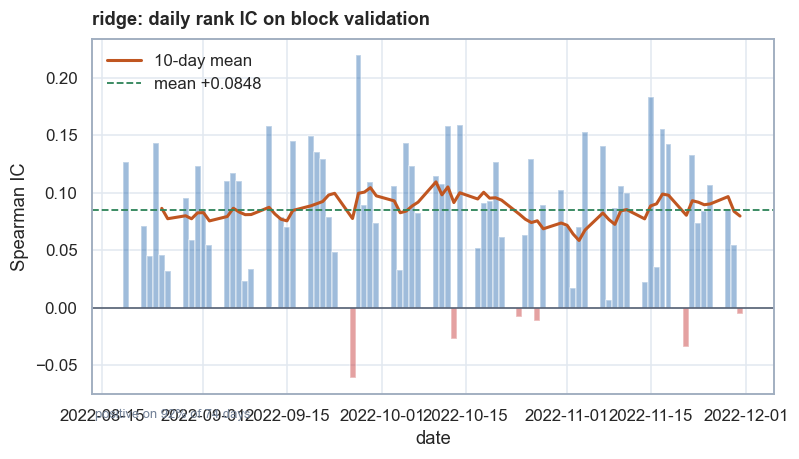

In [39]:
from rvlab.evaluate import daily_rank_ic
from rvlab.plotting import ic_timeseries_plot

winner = report.index[0]
scored = holdout_df[["Date", "Target"]].assign(
    Prediction=everything[winner]).dropna()
ic = daily_rank_ic(scored)
ic_timeseries_plot(ic, window=10, title=f"{winner}: daily rank IC on block validation");

The summary statistics behind that picture.

In [40]:
from rvlab.evaluate import information_ratio

stats = information_ratio(ic)
print(f"mean IC {stats['mean_ic']:+.4f} · ICIR {stats['icir']:+.3f} · "
      f"t-stat {stats['t_stat']:+.1f} · positive on {stats['hit_rate']:.0%} of "
      f"{stats['n_days']} days")

mean IC +0.0848 · ICIR +1.557 · t-stat +13.4 · positive on 92% of 74 days


## R5.24 · Plot what the portfolio would actually have earned
<a id="r5-24"></a>

**Topic** Diagnostics

**Use when** the end of every evaluation. Rank IC measures accuracy; the top-k spread return measures the thing you are scored on. Look at the path with drawdown, not the summary number.

**Inputs** a ranked holdout frame.

**Needs** R5.15, R5.17, R5.21, R5.22, R5.23 — run those first. This recipe builds on what they define.

**Gotchas** a Sharpe driven by a handful of exceptional days is not the same result as a steady one. The cumulative curve makes that visible immediately, and no scalar does.

**See also** [R5.23](#r5-23) (IC path) · [R4.18](when_a_result_is_real.ipynb#r4-18) (tail risk)

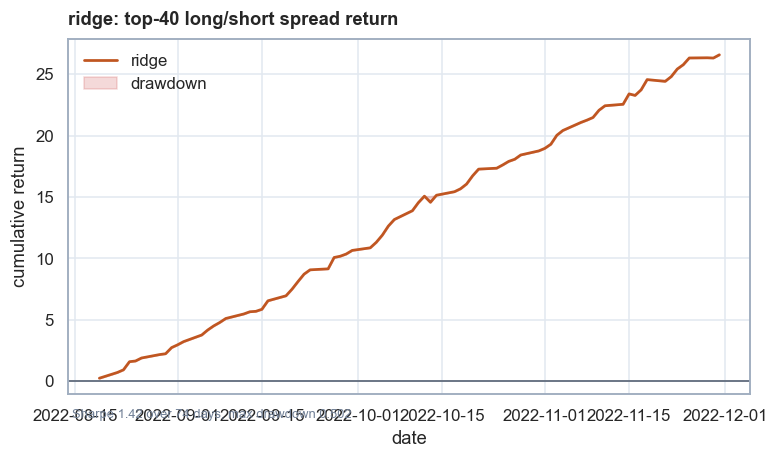

In [41]:
from rvlab.evaluate import add_prediction_rank, spread_return_series
from rvlab.plotting import cumulative_return_plot

ranked = add_prediction_rank(scored)
spread = spread_return_series(ranked, portfolio_size=PORTFOLIO_K)
cumulative_return_plot(spread, label=winner,
                       title=f"{winner}: top-{PORTFOLIO_K} long/short spread return");

And the model comparison as a single picture.

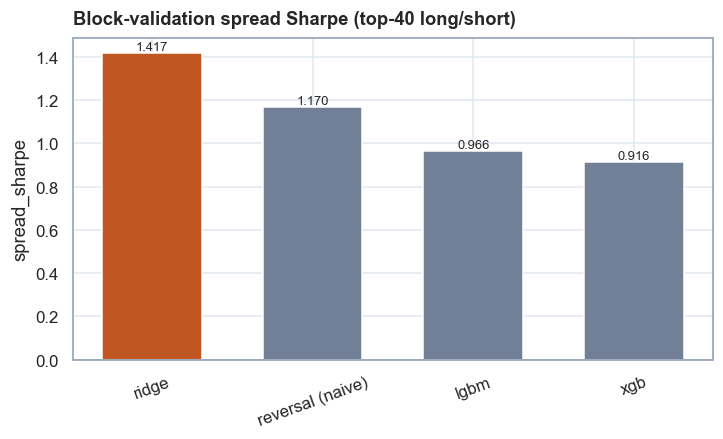

In [42]:
from rvlab.plotting import model_comparison_plot

model_comparison_plot(report, "spread_sharpe",
                      title=f"Block-validation spread Sharpe (top-{PORTFOLIO_K} long/short)");

## Combining models, and shipping one

Blending on a common scale, deciding which importance measure to believe, and the serving contract that a validated model most often fails.

Its data cell binds `categorical`, `dates`, `df`, `fitted`, `holdout_df`, `n_holdout`, `numeric`, `predictions`, `raw_levels`, `selected_params`, `train_df`. It recovers tuned Ridge parameters when the earlier section ran and supplies an explicit standalone default when copied alone; [R5.26](#r5-26) rechecks selection from the current scores.

In [43]:
import numpy as np, pandas as pd
from rvlab.data import load_panel
from rvlab.features import build_panel_features
from rvlab.pipelines import make_panel_pipeline

df = build_panel_features(load_panel(n_entities=N_ENTITIES, n_dates=N_DATES, seed=SEED))
df = df.dropna(subset=["ModelTarget"]).reset_index(drop=True)

identifiers, labels = ["Date", "SecuritiesCode", "RowId", "_source_folder"], ["Target", "ModelTarget"]
categorical = [c for c in ["Sector"] if c in df.columns]
raw_levels = ["Open", "High", "Low", "Close", "Volume", "AdjustmentFactor",
              "ExpectedDividend", "MarketCapitalization", "IssuedShares", "SupervisionFlag"]
numeric = [c for c in df.columns
           if c not in {*identifiers, *labels, *categorical, *raw_levels}
           and df[c].dtype.kind in "fiu"]

dates = pd.DatetimeIndex(np.sort(df["Date"].unique()))
n_holdout = max(1, int(len(dates) * HOLDOUT_FRAC))
train_df = df[df["Date"].isin(dates[:-n_holdout - GAP_DAYS])].reset_index(drop=True)
holdout_df = df[df["Date"].isin(dates[-n_holdout:])].reset_index(drop=True)

selected_params = dict(globals().get("selected_params", {}))
selected_params.setdefault("ridge", {"model__alpha": 100.0})

def configured_pipeline(name):
    model = make_panel_pipeline(name, numeric=numeric, categorical=categorical)
    return model.set_params(**selected_params.get(name, {}))

fitted = {n: configured_pipeline(n).fit(
    train_df[numeric + categorical], train_df["ModelTarget"]) for n in MODELS}
predictions = {n: m.predict(holdout_df[numeric + categorical]) for n, m in fitted.items()}
print(f"{len(fitted)} models fitted on {len(train_df):,} rows; "
      f"reused block validation {len(holdout_df):,} rows")

3 models fitted on 168,800 rows; reused block validation 29,600 rows


## R5.25 · Put predictions on a common scale before averaging them
<a id="r5-25"></a>

**Topic** Ensembling

**Use when** blending any two models. Ridge and a gradient booster can produce predictions with different spreads, so a plain average implicitly gives the wider one more weight. Z-score within each date first.

**Inputs** a dict of prediction arrays and the matching dates.

**Needs** nothing beyond the setup and data cells

**Gotchas** per-date z-scoring costs nothing here because ranking is invariant to a per-date affine transform — the individual models score identically before and after. It only changes the *blend*, which is the point.

**See also** [R5.26](#r5-26) (weights) · [R5.19](the_cross_section.ipynb#r5-19) (scale invariance)

In [44]:
from rvlab.evaluate import cross_sectional_zscore, ranking_report

spreads = {name: float(np.std(pred)) for name, pred in predictions.items()}
print("raw prediction spreads:", {k: round(v, 5) for k, v in spreads.items()})
print(f"widest / narrowest = {max(spreads.values()) / min(spreads.values()):.1f}x")

raw prediction spreads: {'ridge': 0.00229, 'lgbm': 0.00297, 'xgb': 0.00292}
widest / narrowest = 1.3x


A naive average weights models in proportion to their raw spreads rather than solely to the declared coefficients. The printed spread ratio says how material that is here; compare the two blends:

In [45]:
from rvlab.evaluate import blend

naive = np.mean([predictions[n] for n in MODELS], axis=0)
scaled = blend(predictions, holdout_df["Date"])

blend_report = ranking_report(holdout_df, {**predictions, "blend_naive": naive,
                                                "blend_zscored": scaled},
                              portfolio_size=PORTFOLIO_K)
blend_report.round(4)

,rmse,mean_ic,icir,ic_hit_rate,spread_sharpe
model,,,,,
ridge,0.0276,0.0848,1.5572,0.9189,1.4171
blend_zscored,0.9350,0.0778,1.3411,0.8784,1.1887
blend_naive,0.0276,0.0769,1.3169,0.8784,1.1647
lgbm,0.0276,0.0640,1.1611,0.8514,0.9659
xgb,0.0276,0.0694,1.1143,0.8649,0.9157


## R5.26 · Choose blend weights out of sample
<a id="r5-26"></a>

**Topic** Ensembling

**Use when** you want more than an equal-weight average. Weights fitted on the same data you evaluate on will always look better and usually generalise worse.

**Inputs** `predictions` and the holdout.

**Needs** R5.25 — run that first. This recipe compares candidates on the same block.

**Gotchas** equal weights are a strong default and very hard to beat with three correlated models. Fitting weights adds parameters to the part of the pipeline with the least data — judge any apparent improvement against resampling variation and a future test block; there is no universal percentage cutoff.

**See also** [R5.25](#r5-25) (z-scoring first) · [R5.27](#r5-27) (out-of-fold stacking)

In [46]:
from rvlab.evaluate import blend, ranking_report

candidates = {
    "equal": {n: 1.0 for n in MODELS},
    "ridge_heavy": {"ridge": 2.0, "lgbm": 1.0, "xgb": 1.0},
    "trees_only": {"lgbm": 1.0, "xgb": 1.0},
}
blends = {name: blend({k: predictions[k] for k in w}, holdout_df["Date"], w)
          for name, w in candidates.items()}
weight_report = ranking_report(holdout_df, blends, portfolio_size=PORTFOLIO_K)
weight_report.round(4)

,rmse,mean_ic,icir,ic_hit_rate,spread_sharpe
model,,,,,
ridge_heavy,0.9364,0.0809,1.4118,0.9054,1.2938
equal,0.9350,0.0778,1.3411,0.8784,1.1887
trees_only,0.9610,0.0693,1.1479,0.8784,0.9944


> ⚠️ **Reused validation block:** these weights were compared on the same block already used for the base-model table, so it is no longer an untouched holdout. The printed score spread measures the observed selection effect; its magnitude must not be assumed. [R5.27](#r5-27) shows how to learn weights from purged OOF predictions, but a future test block would still be needed for an unbiased final estimate.

In [47]:
individual = blend_report.loc[list(MODELS), "spread_sharpe"].rename(
    index=lambda name: f"model:{name}")
equal_blends = blend_report.loc[["blend_naive", "blend_zscored"], "spread_sharpe"].rename(
    index=lambda name: f"blend:{name}")
weighted_blends = weight_report["spread_sharpe"].rename(
    index=lambda name: f"blend:{name}")
validation_scores = pd.concat([individual, equal_blends, weighted_blends])
winner_key = individual.idxmax()  # blends stay diagnostic; final refit selects one model
selected_model = winner_key.removeprefix("model:")
assert selected_model in fitted and np.isfinite(individual).all()
selected_config = {"model": selected_model,
                   "params": dict(selected_params.get(selected_model, {})),
                   "selection_metric": "spread_sharpe",
                   "selection_value": float(validation_scores[winner_key]),
                   "selection_sample": "reused purged block validation"}
print(f"selected {winner_key} at {individual[winner_key]:.3f}; "
      f"runner-up individual {individual.drop(winner_key).max():.3f}")
selected_config

selected model:ridge at 1.417; runner-up individual 0.966


{'model': 'ridge',
 'params': {'model__alpha': 100.0},
 'selection_metric': 'spread_sharpe',
 'selection_value': 1.4171378011752522,
 'selection_sample': 'reused purged block validation'}

## R5.27 · Generate out-of-fold predictions for stacking
<a id="r5-27"></a>

**Topic** Ensembling

**Use when** you want a meta-model, or honest blend weights. Every row gets a prediction from a model that never saw it, so the meta-level is trained on data the base models did not fit.

**Inputs** `train_df`, the feature lists, and purged folds.

**Needs** R5.26 — run that first. The learned weights are diagnostic after model selection.

**Gotchas** the meta-model must use the *same* purged fold structure, or the stack leaks even though each base model was clean. This is the most common way a stacking pipeline goes wrong.

**See also** [R5.26](#r5-26) (simple weights) · [R3.15](forecasting_the_smile.ipynb#r3-15) (the OOF loop)

In [48]:
from rvlab.evaluate import out_of_fold_predictions, ranking_report
from rvlab.pipelines import make_panel_pipeline, purged_date_splits

folds = purged_date_splits(train_df, n_splits=N_SPLITS, gap_days=GAP_DAYS)
base = {n: configured_pipeline(n) for n in MODELS}
oof = out_of_fold_predictions(base, train_df[numeric + categorical],
                              train_df["ModelTarget"], folds)

mask = ~np.isnan(oof["ridge"])
print(f"{mask.sum():,} of {len(train_df):,} training rows have out-of-fold predictions")

134,400 of 168,800 training rows have out-of-fold predictions


Now the weights can be fitted on data no base model saw. A non-negative least squares keeps the blend interpretable — negative weights on a correlated model are usually an artefact rather than a hedge.

In [49]:
from scipy.optimize import nnls
from rvlab.evaluate import cross_sectional_zscore

X_meta = np.column_stack([cross_sectional_zscore(oof[n][mask],
                                                 train_df["Date"].to_numpy()[mask])
                          for n in MODELS])
weights, _ = nnls(X_meta, train_df["ModelTarget"].to_numpy()[mask])
assert weights.sum() > 0, "NNLS produced no usable blend"
learned = dict(zip(MODELS, np.round(weights / weights.sum(), 3)))
print("weights learned out of fold:", learned)
print(f"diagnostic only; selected configuration remains {selected_model}")

weights learned out of fold: {'ridge': np.float64(0.923), 'lgbm': np.float64(0.077), 'xgb': np.float64(0.0)}
diagnostic only; selected configuration remains ridge


## R5.28 · Read importance out of a fitted pipeline
<a id="r5-28"></a>

**Topic** Interpretability

**Use when** after fitting. A `ColumnTransformer` turns your columns into a few thousand anonymous ones; `get_feature_names_out()` recovers the names — provided every step supports it.

**Inputs** a fitted pipeline whose final step exposes `coef_` or `feature_importances_`.

**Needs** nothing beyond the setup and data cells

**Gotchas** the two quantities are **not comparable**. Gain importance is non-negative and sums to one; a coefficient is signed and depends on scaling. The helper records which one you got in a `kind` column, so a plot cannot be silently mislabelled.

**See also** [R5.29](#r5-29) (grouping) · [R5.30](#r5-30) (the one to believe)

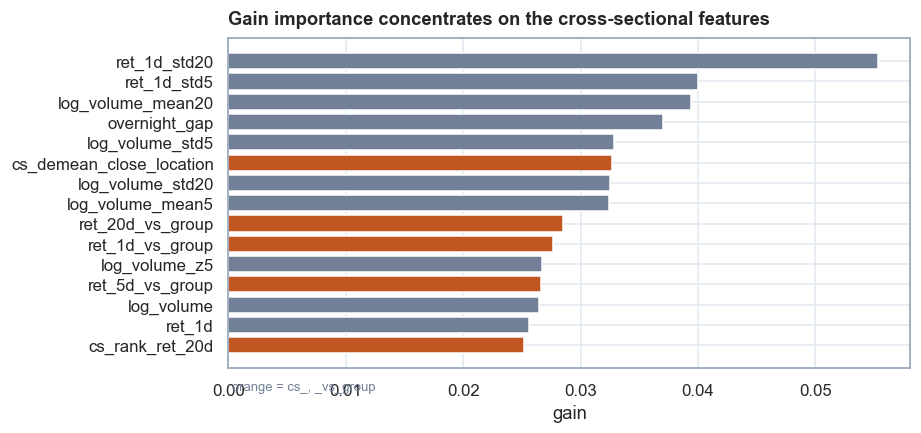

In [50]:
from rvlab.evaluate import pipeline_feature_importance
from rvlab.plotting import importance_plot

top = pipeline_feature_importance(fitted["lgbm"], top_n=15)
importance_plot(top, highlight=("cs_", "_vs_group"),
                title="Gain importance concentrates on the cross-sectional features");

The same question asked of the linear model. Where the two disagree, treat both as hypotheses rather than answers — [R5.30](#r5-30) settles it.

In [51]:
ridge_top = pipeline_feature_importance(fitted["ridge"], top_n=10)
ridge_top.round(4)

,feature,importance,kind
0,overnight_gap,0.0732,abs_coefficient
1,ret_1d,0.0686,abs_coefficient
2,cs_demean_intraday_return,0.0565,abs_coefficient
3,ret_1d_vs_group,0.0465,abs_coefficient
4,cs_rank_ret_1d,0.0457,abs_coefficient
5,cs_rank_log_dollar_volume,0.0400,abs_coefficient
6,intraday_return,0.0383,abs_coefficient
7,cs_demean_ret_1d,0.0342,abs_coefficient
8,cs_demean_ret_20d,0.0334,abs_coefficient
9,ret_20d_vs_group,0.0284,abs_coefficient


## R5.29 · Aggregate one-hot importances back to their source column
<a id="r5-29"></a>

**Topic** Interpretability

**Use when** you have a high-cardinality categorical. A sector with ten levels contributes ten rows of small importance that individually look negligible and jointly may dominate.

**Inputs** an importance frame and a prefix map.

**Needs** nothing beyond the setup and data cells

**Gotchas** this is also how tree importance misleads: a one-hot entity id with 2,000 levels offers many places to split and will look important because of that, not because it predicts. Summing by group makes the comparison against a numeric feature fair.

**See also** [R5.28](#r5-28) (raw importance) · [R4.3](when_a_result_is_real.ipynb#r4-3) (block permutation)

In [52]:
from rvlab.evaluate import group_importance, pipeline_feature_importance

full = pipeline_feature_importance(fitted["lgbm"], top_n=10_000)
group_importance(full, {
    "cross-sectional (cs_*)": "cs_",
    "sector-relative": "_vs_group",
    "raw returns": "ret_",
    "volume": "volume",
    "calendar": "dayof",
    "sector one-hot": "Sector",
}).round(4)

,group,importance,n_features
2,raw returns,0.4196,32
0,cross-sectional (cs_*),0.3022,20
3,volume,0.2628,16
1,sector-relative,0.0829,6
4,calendar,0.0319,2
5,sector one-hot,0.0116,10


## R5.30 · Use permutation importance when the others disagree
<a id="r5-30"></a>

**Topic** Interpretability

**Use when** gain importance and coefficients tell different stories. Permutation importance on the reused *block-validation* data answers how much worse the model gets without this feature on that block.

**Inputs** a fitted pipeline, plus block-validation X and y.

**Needs** nothing beyond the setup and data cells

**Gotchas** it is slow — one refit-free scoring pass per feature per repeat — so subsample the rows. And it still splits credit between correlated features, which is what [R4.3](when_a_result_is_real.ipynb#r4-3)'s block permutation fixes.

**See also** [R5.28](#r5-28) (gain) · [R4.1](when_a_result_is_real.ipynb#r4-1) (the same tool)

In [53]:
from sklearn.inspection import permutation_importance

sample = holdout_df.sample(min(4000, len(holdout_df)), random_state=SEED)
perm = permutation_importance(
    fitted["ridge"], sample[numeric + categorical], sample["ModelTarget"],
    n_repeats=3, random_state=SEED, scoring="neg_mean_absolute_error")

ranked = (pd.DataFrame({"feature": numeric + categorical,
                        "importance": perm.importances_mean})
          .sort_values("importance", ascending=False).head(10).reset_index(drop=True))
ranked.round(6)

,feature,importance
0,cs_demean_intraday_return,7.2000e-05
1,ret_1d,6.0000e-05
2,overnight_gap,5.2000e-05
3,ret_1d_vs_group,4.9000e-05
4,intraday_return,3.5000e-05
5,cs_demean_ret_1d,2.4000e-05
6,cs_demean_ret_20d,2.4000e-05
7,cs_demean_ret_5d,1.9000e-05
8,ret_20d_vs_group,1.8000e-05
9,ret_5d,1.1000e-05


Block-validation permutation is the measure to prefer here: model-agnostic, computed on rows the model did not fit, and denominated in the selected scoring units rather than in a tree's internal bookkeeping. Because the same block was used for model selection, it is diagnostic rather than untouched confirmatory evidence.

It also earns its keep as a **debugging** tool. Raw price levels reflect share count rather than value, so they are not comparable across entities and have no business in a cross-sectional model. [R5.15](the_cross_section.ipynb#r5-15) excludes them explicitly; the check below verifies that none appears in the active top ten instead of quoting stale scores from an earlier feature set.

That is the general lesson. An importance ranking whose top entries make no economic sense is not a curiosity — it is the feature list telling you it is wrong.

In [54]:
print("top 5 by block-validation permutation:", list(ranked["feature"].head(5)))
suspicious = [f for f in ranked["feature"] if f in ("Open", "High", "Low", "Close", "Volume")]
print("raw price levels in the top 10:", suspicious or "none — good")

top 5 by block-validation permutation: ['cs_demean_intraday_return', 'ret_1d', 'overnight_gap', 'ret_1d_vs_group', 'intraday_return']
raw price levels in the top 10: none — good


## R5.31 · Refit on everything once selection is finished
<a id="r5-31"></a>

**Topic** Model selection

**Use when** the very last fitting step. Model choice, hyperparameters and blend weights are all decided; now use every labelled row, because the extra data is free accuracy.

**Inputs** `df` and the chosen configuration.

**Needs** R5.26 — run that first. It records the selected model and parameters.

**Gotchas** do this **after** all diagnostics, never before. Once you include the validation block in the refit there is no clean sample left, so any later number is in-sample — and there is no way to tell that from a prediction array alone.

**See also** [R5.27](#r5-27) (choosing the blend) · [R5.32](#r5-32) (serving it)

In [55]:
from rvlab.pipelines import make_panel_pipeline

assert selected_model == selected_config["model"]
final_model = configured_pipeline(selected_model).fit(
    df[numeric + categorical], df["ModelTarget"])
print(f"refitted selected {selected_model} on {len(df):,} rows "
      f"across {df['Date'].nunique()} dates with {selected_config['params']}")

refitted selected ridge on 199,200 rows across 498 dates with {'model__alpha': 100.0}


## R5.32 · Check the inference schema before predicting
<a id="r5-32"></a>

**Topic** Inference

**Use when** every time test data arrives. Columns go missing, arrive extra, or change order, and a fitted `ColumnTransformer` matches by name while a bare estimator matches by position.

**Inputs** the training feature list and an inference frame.

**Needs** R5.31 — run those first. This recipe builds on what they define.

**Gotchas** a long *missing* list almost always means the feature-engineering function was not applied to the test data — the model will still predict, using imputed medians, and score like noise.

**See also** [R5.33](#r5-33) (streaming) · [R5.34](#r5-34) (submission)

In [56]:
from rvlab.pipelines import align_feature_columns, check_inference_schema

incoming = holdout_df.drop(columns=["cs_rank_ret_1d", "ret_20d"]).assign(unexpected=1.0)
check_inference_schema(numeric + categorical, incoming)

,check,count,examples
0,expected features,47,
1,present,45,
2,missing (imputed),2,"ret_20d, cs_rank_ret_1d"
3,extra (dropped),16,"Date, SecuritiesCode, Open, High, Low, Close"


`align_feature_columns` reconstructs exactly the training schema: missing columns become NaN (so the pipeline's imputer handles them as it handled gaps in training), extras are dropped, and the order is restored.

In [57]:
aligned = align_feature_columns(incoming, numeric + categorical)
print(f"{incoming.shape[1]} incoming columns -> {aligned.shape[1]} aligned")
print(f"{selected_model} prediction runs: {final_model.predict(aligned).shape}")

61 incoming columns -> 47 aligned
ridge prediction runs: (29600,)


## R5.33 · Carry a rolling history buffer for streaming inference
<a id="r5-33"></a>

**Topic** Inference

**Use when** the competition hands you one day at a time and wants a prediction before showing the next. Rolling features need history, so you must keep a buffer — and trim it, or memory grows without bound over a long evaluation.

**Inputs** an initial history frame and a stream of daily frames.

**Needs** nothing beyond the setup and data cells

**Gotchas** `max_days` **must exceed the longest rolling window**. If it does not, the window silently computes on a truncated history and your first live predictions differ from the ones validation produced — with nothing to indicate it.

**See also** [R5.32](#r5-32) (alignment) · [R5.35](#r5-35) (the full loop)

In [58]:
from rvlab.pipelines import RollingHistoryBuffer

raw = load_panel(n_entities=N_ENTITIES, n_dates=N_DATES, seed=SEED)
stream_dates = pd.DatetimeIndex(np.sort(raw["Date"].unique()))[-STREAM_DAYS:]
history = raw[~raw["Date"].isin(stream_dates)]

buffer = RollingHistoryBuffer(history, max_days=BUFFER_DAYS)
print(buffer)
print(f"longest rolling window: 20 days; buffer holds {buffer.n_dates} — "
      f"{'adequate' if buffer.n_dates > 20 else 'TOO SHORT'}")

RollingHistoryBuffer(16,000 rows, 40 dates, max_days=40)
longest rolling window: 20 days; buffer holds 40 — adequate


## R5.34 · Turn predictions into a valid submission
<a id="r5-34"></a>

**Topic** Inference

**Use when** the final step. Predictions become unique integer ranks within each date, in the row order the grader handed you.

**Inputs** the grader's sample frame and a prediction array.

**Needs** R5.26 — run that first. It fixes which validation prediction is submitted.

**Gotchas** two details competitions reject submissions over: ranks must be **unique integers from 0** within each date (so `method="first"`, never `"average"`), and the row order must be the one you were given — so never sort the frame on the way out.

**See also** [R5.33](#r5-33) (the buffer) · [R5.35](#r5-35) (the loop)

In [59]:
from rvlab.pipelines import fill_missing_predictions, rank_for_submission

sample = holdout_df[["Date", "SecuritiesCode"]].head(500).copy()
values = fill_missing_predictions(predictions[selected_model][:500], sample["Date"])
submission = rank_for_submission(sample, values)

per_day = submission.groupby("Date")["Rank"]
print(f"ranks unique within every date: "
      f"{(per_day.nunique() == per_day.size()).all()}")
print(f"every date starts at 0: {(per_day.min() == 0).all()}")
submission.head(3)

ranks unique within every date: True
every date starts at 0: True


,Date,SecuritiesCode,Rank
0,2022-08-19,1301,300
1,2022-08-19,1302,27
2,2022-08-19,1303,326


## R5.35 · Run the streaming loop end to end before you trust it
<a id="r5-35"></a>

**Topic** Inference

**Use when** before submitting. Replay the last few days one at a time through the exact code path the live API will use, and check the predictions match what a batch run produces.

**Inputs** the buffer, the fitted model and the feature function.

**Needs** R5.31, R5.33 — run those first. This recipe builds on what they define.

**Gotchas** the parity check at the end is the point. If streaming and batch disagree, the cause is almost always the buffer being too short or a feature that quietly depends on the whole sample — and you want to find that here rather than in a scored submission.

**See also** [R5.33](#r5-33) (the buffer) · [R5.34](#r5-34) (submission format)

In [60]:
from rvlab.features import build_panel_features
from rvlab.pipelines import align_feature_columns, rank_for_submission

streamed = []
for day in stream_dates:
    today = raw[raw["Date"] == day]
    frame = buffer.append(today)                       # history + today
    features = build_panel_features(frame)
    current = features[features["Date"] == day]

    X = align_feature_columns(current, numeric + categorical)
    current = current.assign(Prediction=final_model.predict(X))
    streamed.append(current[["Date", "SecuritiesCode", "Prediction"]])

streamed = pd.concat(streamed, ignore_index=True)
print(f"streamed {len(stream_dates)} days, {len(streamed):,} predictions")

streamed 12 days, 4,800 predictions


The parity check. A batch run over the same dates should reproduce the streamed predictions closely — not bit-for-bit, because the buffer gives rolling windows less history than the full panel does, but closely enough that the *ranking* is essentially identical.

In [61]:
from scipy.stats import spearmanr

batch = build_panel_features(raw)
batch = batch[batch["Date"].isin(stream_dates)]
batch = batch.assign(Prediction=final_model.predict(
    align_feature_columns(batch, numeric + categorical)))

merged = streamed.merge(batch[["Date", "SecuritiesCode", "Prediction"]],
                        on=["Date", "SecuritiesCode"], suffixes=("_stream", "_batch"))
rho = spearmanr(merged["Prediction_stream"], merged["Prediction_batch"]).statistic
assert rho > 0.99, f"streaming/batch parity failed: rho={rho:.4f}"
print(f"{selected_model} streaming vs batch rank correlation: {rho:.4f}")

ridge streaming vs batch rank correlation: 1.0000


## R5.36 · Write a manifest so the run can be reproduced
<a id="r5-36"></a>

**Topic** Reproducibility

**Use when** the moment a result goes into a document or a submission. Record the data provenance, the configuration, the library versions and the seed next to the numbers.

**Inputs** the fitted configuration and `rvlab.config.OUTPUT_DIR`.

**Needs** R5.34 — run those first. This recipe builds on what they define.

**Gotchas** record the *input* identity, not just the filename. A rerun against silently updated data is the failure this catches, and a path alone will not catch it.

**See also** [R4.14](when_a_result_is_real.ipynb#r4-14) (sweep manifests) · [R4.21](when_a_result_is_real.ipynb#r4-21) (exporting)

In [62]:
import json, sys, sklearn
from rvlab.config import OUTPUT_DIR
from rvlab.data import provenance

manifest = {
    "task": "panel cross-sectional ranking",
    "data": provenance(df) or df.attrs.get("provenance", {}),
    "n_rows": len(df), "n_dates": int(df["Date"].nunique()),
    "n_features": len(numeric) + len(categorical),
    "models_compared": list(MODELS), "selected_model": selected_model,
    "selected_config": selected_config, "tuned_params": selected_params,
    "portfolio_k": PORTFOLIO_K,
    "cv": {"n_splits": N_SPLITS, "gap_days": GAP_DAYS, "holdout_frac": HOLDOUT_FRAC},
    "seed": SEED, "python": sys.version.split()[0], "sklearn": sklearn.__version__,
}
(OUTPUT_DIR / "panel_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(json.dumps(manifest, indent=2, default=str)[:520])

{
  "task": "panel cross-sectional ranking",
  "data": {
    "source": "synthetic",
    "synthetic": true,
    "rows": 200000,
    "planted_effect": "short-term reversal, coefficient 0.1",
    "hint": "set $RVLAB_PANEL_ROOT to an unzipped competition directory"
  },
  "n_rows": 199200,
  "n_dates": 498,
  "n_features": 47,
  "models_compared": [
    "ridge",
    "lgbm",
    "xgb"
  ],
  "selected_model": "ridge",
  "selected_config": {
    "model": "ridge",
    "params": {
      "model__alpha": 100.0
    },
    "se


The submission and its manifest, written together — the pair that survives the notebook.

In [63]:
submission[["Date", "SecuritiesCode", "Rank"]].to_csv(
    OUTPUT_DIR / "submission_example.csv", index=False)
for f in sorted(OUTPUT_DIR.glob("*.csv")) + sorted(OUTPUT_DIR.glob("*.json")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

  submission_example.csv  (9.6 KB)
  panel_manifest.json  (0.9 KB)


## Verdict & what carries forward

A panel analysis is credible when its machinery matches its unit of observation:

* historical transforms stay within entity and same-date transforms are used only when the
  full cross-section is available at prediction time;
* folds move whole dates and purge at least the forward label horizon;
* model selection uses the declared ranking objective, with naive reversal shown beside it;
* the best supported individual model is selected dynamically—no fixture-specific winner is
  assumed—and every refit and inference path uses that recorded configuration; and
* schema, row order and streaming/batch parity are checked before a submission is trusted.

Blending, three importance measures, streaming and manifests remain useful extensions. For a
timed end-to-end version, return to the [volatility project panel notebook](volatility_project_03_panel.ipynb).